# Hierarchical ITS for staggered launches (event-study)

This notebook demonstrates `HierarchicalInterruptedTimeSeries`, a multi-unit ITS
design where each unit (e.g. a product) has its **own** treatment time. Per-unit
intercepts, covariate slopes and the launch "lift" are partially pooled toward
shared population-level hyperparameters, so sparse units borrow strength from
well-observed ones and we recover a posterior over the population effect that
can be used to forecast the impact of a *new* launch.

Three effect parameterizations are available:

- `effect_type='instant'` &mdash; a single post-launch level shift per unit.
- `effect_type='event_study'` &mdash; dynamic effects across post-launch event-time bins.
- `effect_type='placebo'` &mdash; the event-study form extended with pre-launch leads as placebos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import causalpy as cp
from causalpy.pymc_models import HierarchicalLaunchITS

rng = np.random.default_rng(42)

## Shared simulation utilities

Each of the three model variants is designed to handle a different kind of
treatment effect, so in the sections below we simulate a **different** panel
for each one to show how faithfully it recovers the truth. The helpers below
build a panel of `N_PRODUCTS` products observed weekly over `T` weeks with
per-product intercepts, covariate slopes, shared seasonality, and a
user-supplied effect function `effect_fn(tau)` that returns the true causal
contribution for a given event time `tau = week - launch_week`.

In [2]:
N_PRODUCTS = 15
T = 200


def fourier_terms(t, period=52, K=2):
    cols = []
    for k in range(1, K + 1):
        cols.append(np.sin(2 * np.pi * k * t / period))
        cols.append(np.cos(2 * np.pi * k * t / period))
    return np.column_stack(cols)


def simulate_panel(effect_fn, seed, n_products=N_PRODUCTS, T=T):
    """Simulate a staggered-launch panel with a user-supplied effect function.

    ``effect_fn(tau, i)`` receives event time (weeks since launch) and the
    product index and returns the true causal contribution to sales.
    """
    rng = np.random.default_rng(seed)
    alpha = rng.normal(50, 8, n_products)
    gamma = rng.normal(0.15, 0.03, n_products)
    delta = rng.normal(-0.6, 0.1, n_products)
    launch_week = rng.integers(40, T - 80, n_products)

    week_idx = np.arange(T)
    season = fourier_terms(week_idx) @ np.array([6.0, -3.0, 2.0, -1.5])

    rows = []
    for i in range(n_products):
        emails = rng.normal(120, 25, T)
        price = rng.normal(20, 2, T)
        tau = week_idx - launch_week[i]
        effect = effect_fn(tau, i, rng)
        sales = (
            alpha[i]
            + gamma[i] * emails
            + delta[i] * price
            + season
            + effect
            + rng.normal(0, 4, T)
        )
        rows.append(
            pd.DataFrame(
                {
                    "product": i,
                    "week_idx": week_idx,
                    "launch_week": launch_week[i],
                    "sales": sales,
                    "emails": emails,
                    "price": price,
                }
            )
        )
    return pd.concat(rows, ignore_index=True)

## Instant lift model

**DGP:** a flat post-launch step of size `lift_i ~ N(12, 4)`. Each product's
effect is constant from the launch week onwards — the simplest causal story
and the one the `instant` model is designed for.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_beta, sigma_beta, z_beta, beta_season, mu_lift, sigma_lift, z_lift, sigma]
/Users/nathanielforde/mambaforge/envs/CausalPy/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 91 seconds.
Sampling: [beta_season, mu_alpha, mu_beta, mu_lift, sigma, sigma_alpha, sigma_beta, sigma_lift, y_hat, z_alpha, z_beta, z_lift]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: instant
Units: 15
E[mu_lift] = 11.9   E[sigma_lift] = 2.92


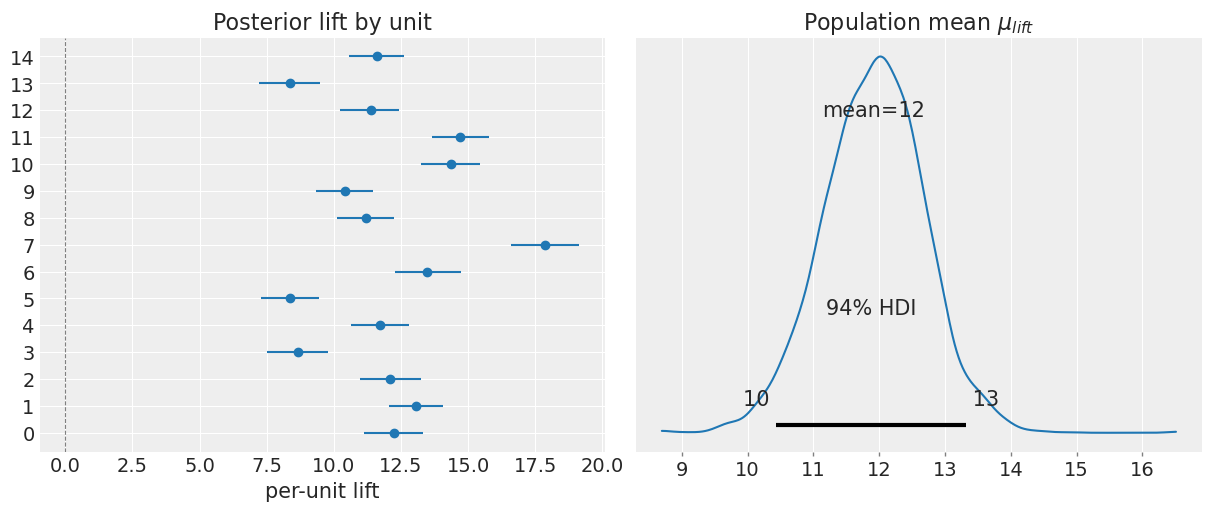

In [3]:
TRUE_MU_LIFT = 12.0
TRUE_SIGMA_LIFT = 4.0
_lift_rng = np.random.default_rng(7)
_lift_i = _lift_rng.normal(TRUE_MU_LIFT, TRUE_SIGMA_LIFT, N_PRODUCTS)


def instant_effect(tau, i, rng):
    return _lift_i[i] * (tau >= 0).astype(float)


df_instant = simulate_panel(instant_effect, seed=0)

result_instant = cp.HierarchicalInterruptedTimeSeries(
    data=df_instant,
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="instant",
    seasonality={"period": 52, "K": 2},
    model=HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.95,
            "random_seed": 42,
            "progressbar": False,
        }
    ),
)
result_instant.summary()
result_instant.plot();

### Predictive distribution for a *new* launch

Because the model has a posterior over the population hyperparameters, we can
sample the lift we would expect from a yet-unobserved product.

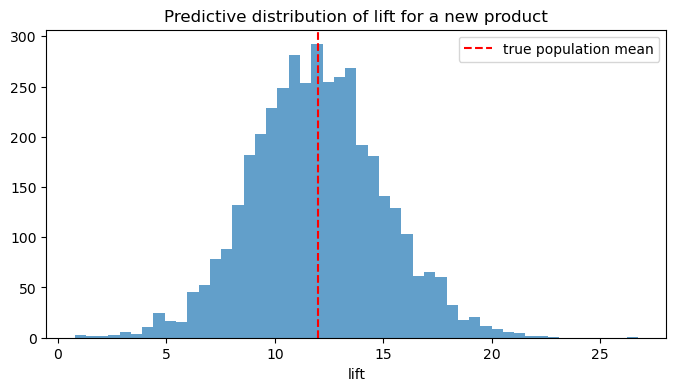

In [4]:
new_lift = result_instant.predictive_for_new_unit(size=4000, random_seed=0)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(new_lift, bins=50, alpha=0.7)
ax.axvline(TRUE_MU_LIFT, color="red", ls="--", label="true population mean")
ax.set_title("Predictive distribution of lift for a new product")
ax.set_xlabel("lift")
ax.legend()
plt.show()

## Event-study (dynamic) model

**DGP:** a realistic launch curve — awareness ramps up over the first few
weeks, peaks around week 8, then decays toward a lower long-run level as
novelty wears off. A single "instant" lift would average this over time and
miss the story entirely; the event-study variant estimates a separate
population effect per post-launch bin and should trace out the true curve.

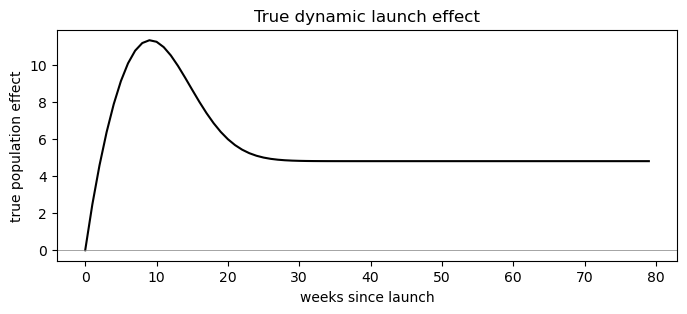

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_beta, sigma_beta, z_beta, beta_season, mu_delta, sigma_delta, z_delta, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 200 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_delta, sigma, sigma_alpha, sigma_beta, sigma_delta, y_hat, z_alpha, z_beta, z_delta]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: event_study
Units: 15
  [0,4)               mu_delta = +4.22
  [4,8)               mu_delta = +9.38
  [8,12)              mu_delta = +11.6
  [12,16)             mu_delta = +10.3
  [16,20)             mu_delta = +6.87
  [20,26)             mu_delta = +5.56
  [26,39)             mu_delta = +4.6
  [39,52)             mu_delta = +5.18
  [52,78)             mu_delta = +4.76
  [78,10000)          mu_delta = +4.87


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/hierarchical_interrupted_time_series.py:498: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


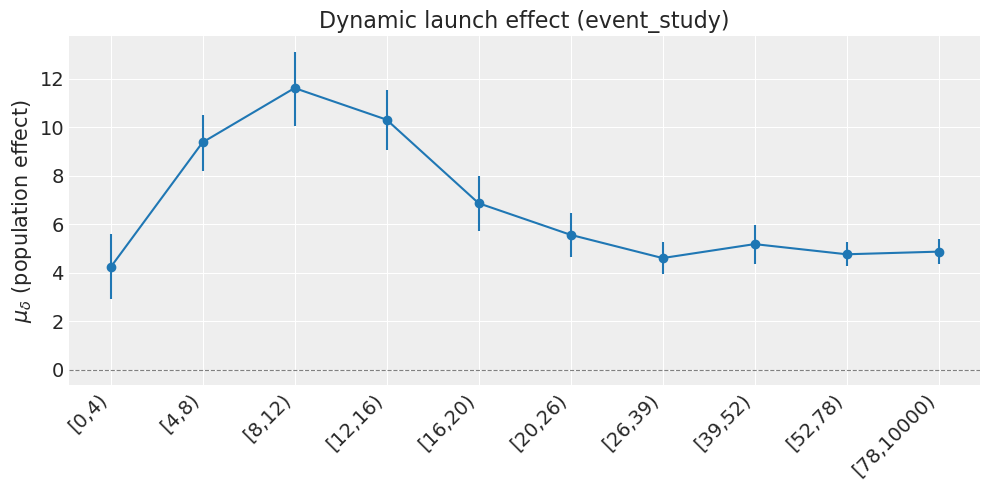

In [5]:
TRUE_MU_AMP = 12.0
TRUE_SIGMA_AMP = 3.0
_amp_rng = np.random.default_rng(11)
_amp_i = _amp_rng.normal(TRUE_MU_AMP, TRUE_SIGMA_AMP, N_PRODUCTS)


def launch_shape(tau):
    """Ramp-up, peak around week 8, decay toward ~40% long-run level."""
    tau = np.asarray(tau, dtype=float)
    return np.where(
        tau < 0,
        0.0,
        (1 - np.exp(-tau / 3.0)) * (0.4 + 0.6 * np.exp(-((tau - 8.0) ** 2) / 80.0)),
    )


def dynamic_effect(tau, i, rng):
    return _amp_i[i] * launch_shape(tau)


df_event = simulate_panel(dynamic_effect, seed=1)

# Show the true population event-time curve we expect to recover.
tau_grid = np.arange(0, 80)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_grid, TRUE_MU_AMP * launch_shape(tau_grid), color="black")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("weeks since launch")
ax.set_ylabel("true population effect")
ax.set_title("True dynamic launch effect")
plt.show()

result_event = cp.HierarchicalInterruptedTimeSeries(
    data=df_event,
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="event_study",
    bin_edges=[0, 4, 8, 12, 16, 20, 26, 39, 52, 78, 10000],
    seasonality={"period": 52, "K": 2},
    model=HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.95,
            "random_seed": 42,
            "progressbar": False,
        }
    ),
)
result_event.summary()
result_event.plot();

## Placebo (lead/lag) model

**DGP:** we generate *two* panels from the **same random seed** (so the noise,
covariates and launch weeks are identical) but with different treatment effects:

1. **With anticipation** — the ramp/peak/decay post-launch curve plus a
   deliberate pre-launch linear build-up over the 8 weeks before launch
   (e.g. a pre-order period). The placebo bins in `[-8, -4)` and `[-4, 0)`
   should absorb this and the automatic check should **fail**.
2. **Without anticipation** — the same post-launch dynamics but strictly zero
   before launch. The placebo bins should be indistinguishable from zero and
   the check should **pass**.

Because the only difference between the two panels is the anticipation
component, the contrast isolates exactly what the placebo test is designed
to detect.

=== Panel WITH anticipation (placebo check should FAIL) ===


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_beta, sigma_beta, z_beta, beta_season, mu_delta, sigma_delta, z_delta, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 508 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_delta, sigma, sigma_alpha, sigma_beta, sigma_delta, y_hat, z_alpha, z_beta, z_delta]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: placebo
Units: 15
  pre[-26,-20)        mu_delta = +0.271
  pre[-20,-16)        mu_delta = +0.723
  pre[-16,-12)        mu_delta = +0.00895
  pre[-12,-8)         mu_delta = -0.235
  pre[-8,-4)          mu_delta = +1.28
  pre[-4,0)           mu_delta = +4.31
  post[0,4)           mu_delta = +3.61
  post[4,8)           mu_delta = +9.81
  post[8,12)          mu_delta = +12.8
  post[12,16)         mu_delta = +10.5
  post[16,20)         mu_delta = +7.76
  post[20,26)         mu_delta = +6.06
  post[26,39)         mu_delta = +5.58
  post[39,52)         mu_delta = +5.03
  post[52,78)         mu_delta = +5.46
  post[78,10000)      mu_delta = +5.16
Placebo check: FAIL (5/6 pre-launch bins contain 0 within the 94% HDI)


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/hierarchical_interrupted_time_series.py:498: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


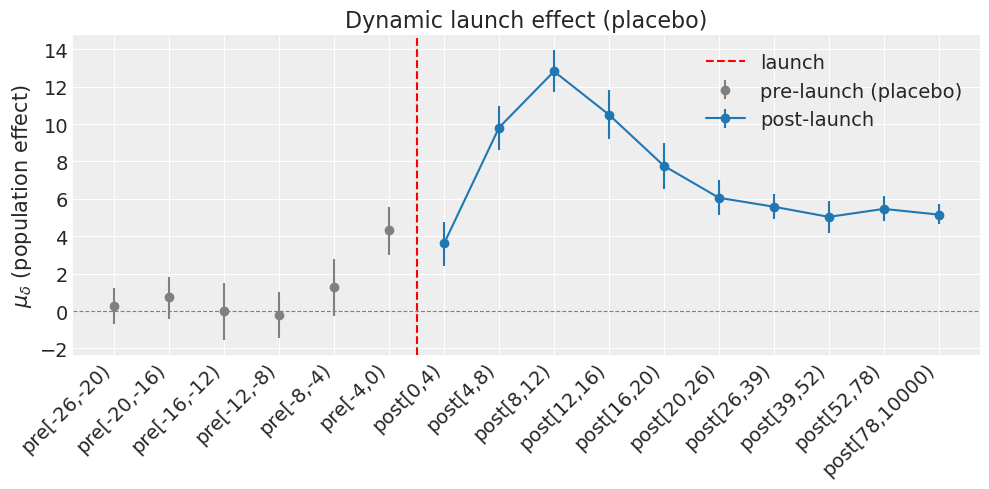

In [6]:
def anticipation_effect(tau, i, rng):
    """Dynamic post-launch effect + pre-launch build-up over 8 weeks."""
    post = _amp_i[i] * launch_shape(tau)
    tau_arr = np.asarray(tau, dtype=float)
    lead = np.where(
        (tau_arr >= -8) & (tau_arr < 0),
        _amp_i[i] * 0.4 * (tau_arr + 8) / 8.0,  # linear ramp up to ~40% of amp
        0.0,
    )
    return post + lead


def clean_dynamic_effect(tau, i, rng):
    """Same post-launch dynamics, but strictly zero before launch."""
    return _amp_i[i] * launch_shape(tau)


# Same seed → identical noise; only difference is the anticipation component
df_placebo_bad = simulate_panel(anticipation_effect, seed=2)
df_placebo_clean = simulate_panel(clean_dynamic_effect, seed=2)


def make_placebo_model():
    return HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.97,
            "random_seed": 42,
            "progressbar": False,
        }
    )


placebo_kwargs = dict(
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="placebo",
    bin_edges=[0, 4, 8, 12, 16, 20, 26, 39, 52, 78, 10000],
    placebo_edges=[-26, -20, -16, -12, -8, -4, 0],
    seasonality={"period": 52, "K": 2},
)

print("=== Panel WITH anticipation (placebo check should FAIL) ===")
result_placebo_bad = cp.HierarchicalInterruptedTimeSeries(
    data=df_placebo_bad, model=make_placebo_model(), **placebo_kwargs
)
result_placebo_bad.summary()
result_placebo_bad.plot();

=== Same noise, NO anticipation (placebo check should PASS) ===


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_beta, sigma_beta, z_beta, beta_season, mu_delta, sigma_delta, z_delta, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 501 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_delta, sigma, sigma_alpha, sigma_beta, sigma_delta, y_hat, z_alpha, z_beta, z_delta]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: placebo
Units: 15
  pre[-26,-20)        mu_delta = +0.251
  pre[-20,-16)        mu_delta = +0.722
  pre[-16,-12)        mu_delta = -0.0343
  pre[-12,-8)         mu_delta = -0.255
  pre[-8,-4)          mu_delta = +0.353
  pre[-4,0)           mu_delta = +0.889
  post[0,4)           mu_delta = +3.6
  post[4,8)           mu_delta = +9.8
  post[8,12)          mu_delta = +12.8
  post[12,16)         mu_delta = +10.5
  post[16,20)         mu_delta = +7.76
  post[20,26)         mu_delta = +6.05
  post[26,39)         mu_delta = +5.56
  post[39,52)         mu_delta = +5.03
  post[52,78)         mu_delta = +5.45
  post[78,10000)      mu_delta = +5.14
Placebo check: PASS (6/6 pre-launch bins contain 0 within the 94% HDI)


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/hierarchical_interrupted_time_series.py:498: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


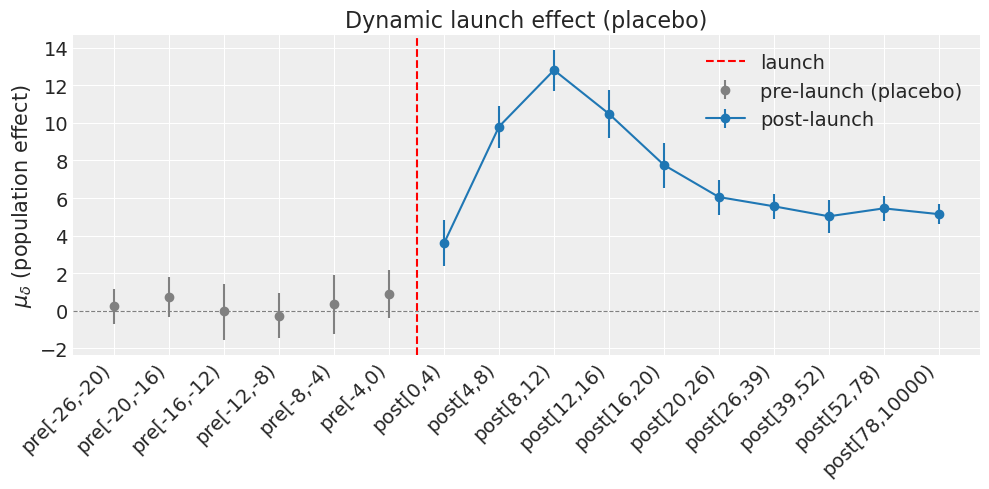

In [7]:
print("=== Same noise, NO anticipation (placebo check should PASS) ===")
result_placebo_ok = cp.HierarchicalInterruptedTimeSeries(
    data=df_placebo_clean, model=make_placebo_model(), **placebo_kwargs
)
result_placebo_ok.summary()
result_placebo_ok.plot();

## Notes on the implementation

- All hierarchical parameters use a non-centered parametrization for sampler health.
- Priors on population-level scale parameters are derived from the data via
  `priors_from_data` so the model is approximately scale-invariant.
- Covariates from the patsy formula are standardized internally; the
  hierarchical $\alpha$ takes the place of an intercept (you should not
  include one in `formula`).
- Any prior can be overridden via the `priors=` argument to
  `HierarchicalLaunchITS` using the `pymc_extras.prior.Prior` system.